# Fine Tune on 100% data with 101 food classes


In [ ]:
!wget https://raw.githubusercontent.com/umerkang66/ai-ml-dl/refs/heads/master/tensorflow-bootcamp/03-computer-vision-tf/helper_functions.py

--2026-07-08 18:24:36--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py.2’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-07-08 18:24:36 (91.6 MB/s) - ‘helper_functions.py.2’ saved [10246/10246]



In [6]:
import warnings

warnings.filterwarnings("ignore")

from helper_functions import plot_loss_curves, compare_historys

## Get the Data from Tensorflow Datasets


In [7]:
import tensorflow_datasets as tfds

In [8]:
(train_data, test_data), ds_info = tfds.load(
    name="food101",
    split=["train", "validation"],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

In [10]:
import tensorflow as tf

train_size = tf.data.experimental.cardinality(train_data).numpy()
test_size = tf.data.experimental.cardinality(test_data).numpy()

print(f"Train size: {train_size}")
print(f"Test size: {test_size}")

Train size: 75750
Test size: 25250


In [11]:
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [12]:
classnames = ds_info.features["label"].names

In [13]:
import matplotlib.pyplot as plt
import random


def show_random_image(dataset=train_data, ds_info=ds_info, n=3):
    # Get class names from ds_info
    class_names = ds_info.features["label"].names

    plt.figure(figsize=(15, 5))

    # Shuffle a large buffer, then grab n examples
    for i, (image, label) in enumerate(dataset.shuffle(buffer_size=1000).take(n)):
        plt.subplot(1, n, i + 1)
        plt.imshow(image.numpy().astype("uint8"))
        plt.title(f"Class: {class_names[label.numpy()]}\nShape: {image.shape}")
        plt.axis(False)

    plt.show()

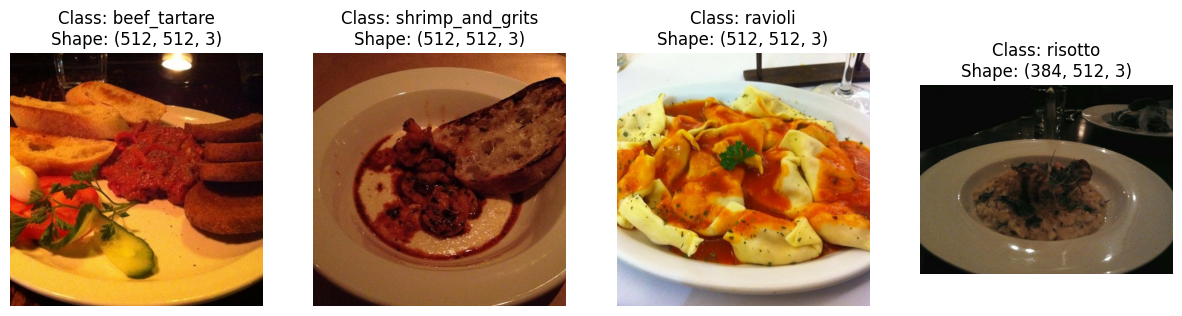

In [14]:
show_random_image(train_data, ds_info, n=4)

In [15]:
import tensorflow as tf

for image, label in train_data.take(1):
    print(image.shape, label.numpy())

tf.reduce_min(image), tf.reduce_max(image)

(512, 512, 3) 43


(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Batch and prepare dataset


In [16]:
def preprocess_img(image, label, img_shape=224):
    """
    Converts image datatype from 'uint8' -> 'float32' and reshapes image to [img_shape, img_shape, color_channels]
    """
    image = tf.image.resize(image, [img_shape, img_shape])
    return (
        tf.cast(image, tf.float32),
        label,
    )  # return the tuple of (float32_imaage, label)

In [17]:
train_data = train_data.map(
    map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE
)
# shuffling train_data just to be sure
# but when loading the data it was already shuffled
train_data = (
    train_data.shuffle(buffer_size=1000)
    .batch(32)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

test_data = test_data.map(map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
# shuffling same as train data
test_data = (
    test_data.shuffle(buffer_size=1000).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)
)

In [18]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

## Model Callbacks


In [19]:
checkpoint_path = "model_checkpoint/cp.weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

## Mixed Precision


In [20]:
# Mixed precision utilizes a combination of float32 and float16 data types to speed up model performance

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

## Training (Feature Extraction)


In [21]:
input_shape = (224, 224, 3)

base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

inputs = tf.keras.layers.Input(shape=input_shape, name="input_layer")
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(
    len(classnames), activation="softmax", dtype=tf.float32
)(x)

model_1 = tf.keras.Model(inputs, outputs)

# compiling
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",  # label is in integer form, use sparse_categorical_cross_entropy
    metrics=["accuracy"],
)

# training
history_1 = model_1.fit(
    train_data,
    epochs=3,
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)),
    callbacks=[model_checkpoint, early_stopping],
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4753 - loss: 2.2913
Epoch 1: val_accuracy improved from None to 0.69995, saving model to model_checkpoint/cp.weights.h5

Epoch 1: finished saving model to model_checkpoint/cp.weights.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 323s 97ms/step - accuracy: 0.5690 - loss: 1.7749 - val_accuracy: 0.6999 - val_loss: 1.1400
Epoch 2/3
2367/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6670 - loss: 1.2857
Epoch 2: val_accuracy improved from 0.69995 to 0.72113, saving model to model_checkpoint/cp.weights.h5

Epoch 2: finished saving model to model_checkpoint/cp.weights.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 177s 74ms/step - accuracy: 0.6706 - loss: 1.2683 - val_accuracy: 0.7211 - val_loss: 1.0181
Epoch 3/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7052 - loss: 1.1342
Epoch 3: val_accuracy improved from 0.72113 to 0.72378, saving model to model_checkpoint/cp.weights.h5

Ep

In [22]:
model_1.save("./feature_extracted_model.keras")

In [23]:
results_1 = model_1.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 89s 111ms/step - accuracy: 0.7277 - loss: 1.0023


In [24]:
model_2 = model_1

base_model = model_2.layers[1]
base_model.trainable = True

# refreeze every layer except the last 10
for layer in base_model.layers[:-10]:
    layer.trainable = False

model_2.compile(
    loss="sparse_categorical_crossentropy",  # use "sparse_categorical_crossentropy" if your labels are integers, not one-hot
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),  # during fine tuning lower the learning rate by 10x
    metrics=["accuracy"],
)

epochs = 3
fine_tune_epochs = epochs + 3

history_2 = model_2.fit(
    train_data,
    epochs=fine_tune_epochs,
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)),
    initial_epoch=history_1.epoch[-1],
)

Epoch 3/6
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 260s 88ms/step - accuracy: 0.7323 - loss: 1.0178 - val_accuracy: 0.7540 - val_loss: 0.8963
Epoch 4/6
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 162s 67ms/step - accuracy: 0.7670 - loss: 0.8822 - val_accuracy: 0.7638 - val_loss: 0.8513
Epoch 5/6
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 167s 70ms/step - accuracy: 0.7883 - loss: 0.7945 - val_accuracy: 0.7656 - val_loss: 0.8385
Epoch 6/6
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 161s 67ms/step - accuracy: 0.8073 - loss: 0.7254 - val_accuracy: 0.7744 - val_loss: 0.8044


In [25]:
model_2.save("./fine_tuned_model.keras")

In [26]:
results_2 = model_2.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 64s 79ms/step - accuracy: 0.7702 - loss: 0.8220


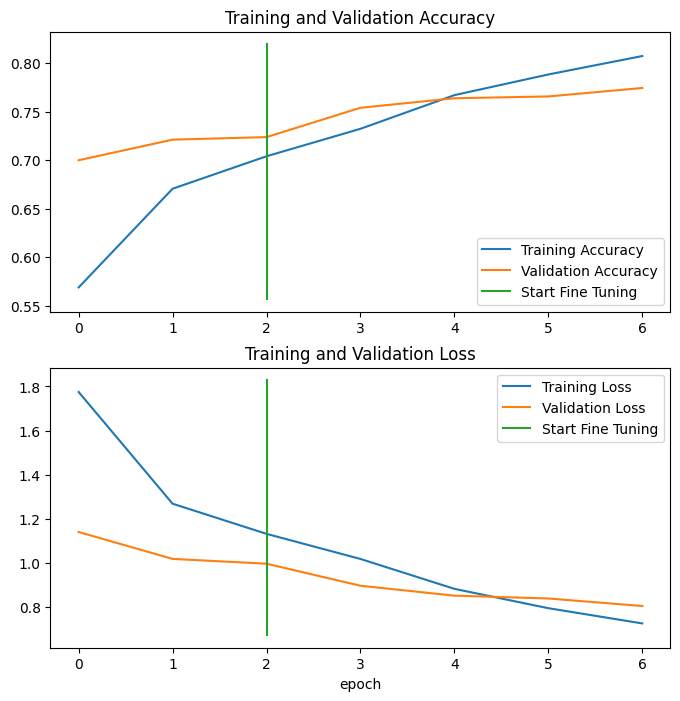

In [27]:
compare_historys(history_1, history_2, initial_epochs=3)

## Ploting random results


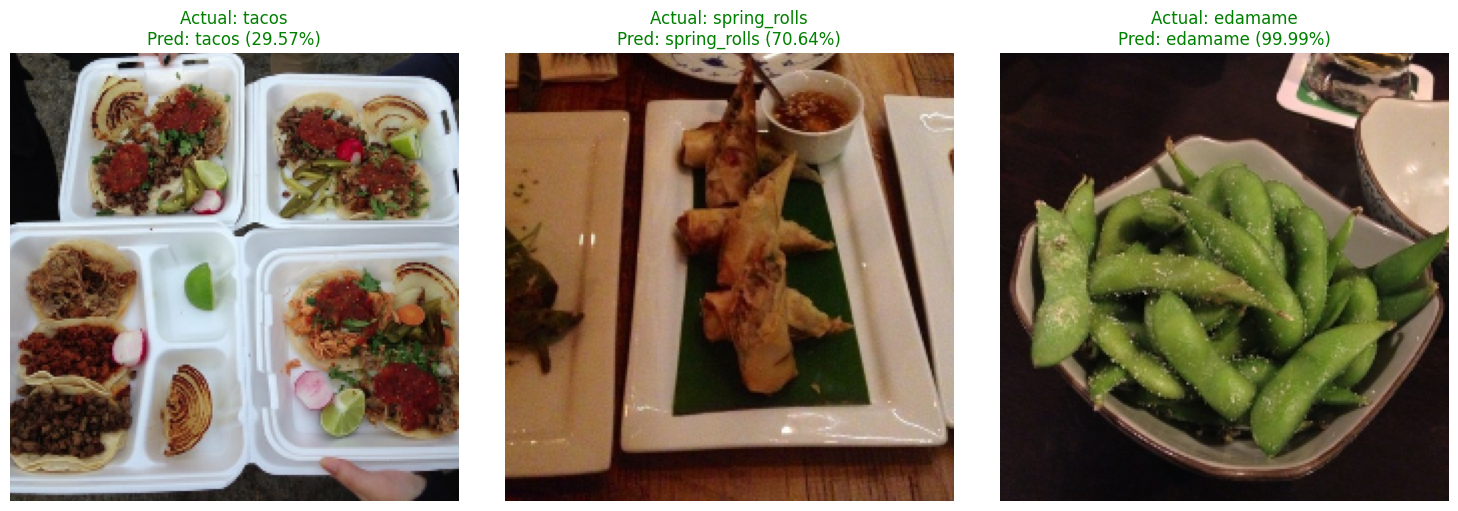

In [28]:
import random
import matplotlib.pyplot as plt
import tensorflow as tf

class_names = ds_info.features["label"].names

# Shuffle ONCE with a much smaller buffer, grab ONE batch
for images, labels in test_data.shuffle(buffer_size=32).take(1):
    batch_images, batch_labels = images, labels

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
indices = random.sample(range(batch_images.shape[0]), 3)

for ax, idx in zip(axes, indices):
    img = batch_images[idx]
    true_label = class_names[batch_labels[idx].numpy()]

    pred_probs = model_2.predict(tf.expand_dims(img, axis=0), verbose=0)
    pred_class = class_names[pred_probs.argmax()]
    conf_score = pred_probs.max()

    ax.imshow(img / 255.0)
    title_color = "green" if pred_class == true_label else "red"
    ax.set_title(f"Actual: {true_label}\nPred: {pred_class} ({conf_score:.2%})", color=title_color)
    ax.axis(False)

plt.tight_layout()
plt.show()

## Confusion Matrix


In [29]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix


def make_confusion_matrix(
    y_true,
    y_pred,
    classes=None,
    figsize=(10, 10),
    text_size=15,
    norm=False,
    savefig=False,
):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    n_classes = cm.shape[0]

    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)

    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])

    ax.set(
        title="Confusion Matrix",
        xlabel="Predicted label",
        ylabel="True label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels,
    )

    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()
    plt.xticks(rotation=70, fontsize=text_size)
    plt.yticks(fontsize=text_size)

    threshold = (cm.max() + cm.min()) / 2.0

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if norm:
            plt.text(
                j,
                i,
                f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=text_size,
            )
        else:
            plt.text(
                j,
                i,
                f"{cm[i, j]}",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=text_size,
            )

    if savefig:
        fig.savefig("confusion_matrix.png")

In [35]:
y_labels = []
pred_classes = []

for images, labels in test_data:
    preds = model_2.predict(images, verbose=0)
    pred_classes.extend(preds.argmax(axis=1))
    y_labels.extend(labels.numpy())

y_labels = np.array(y_labels)
pred_classes = np.array(pred_classes)

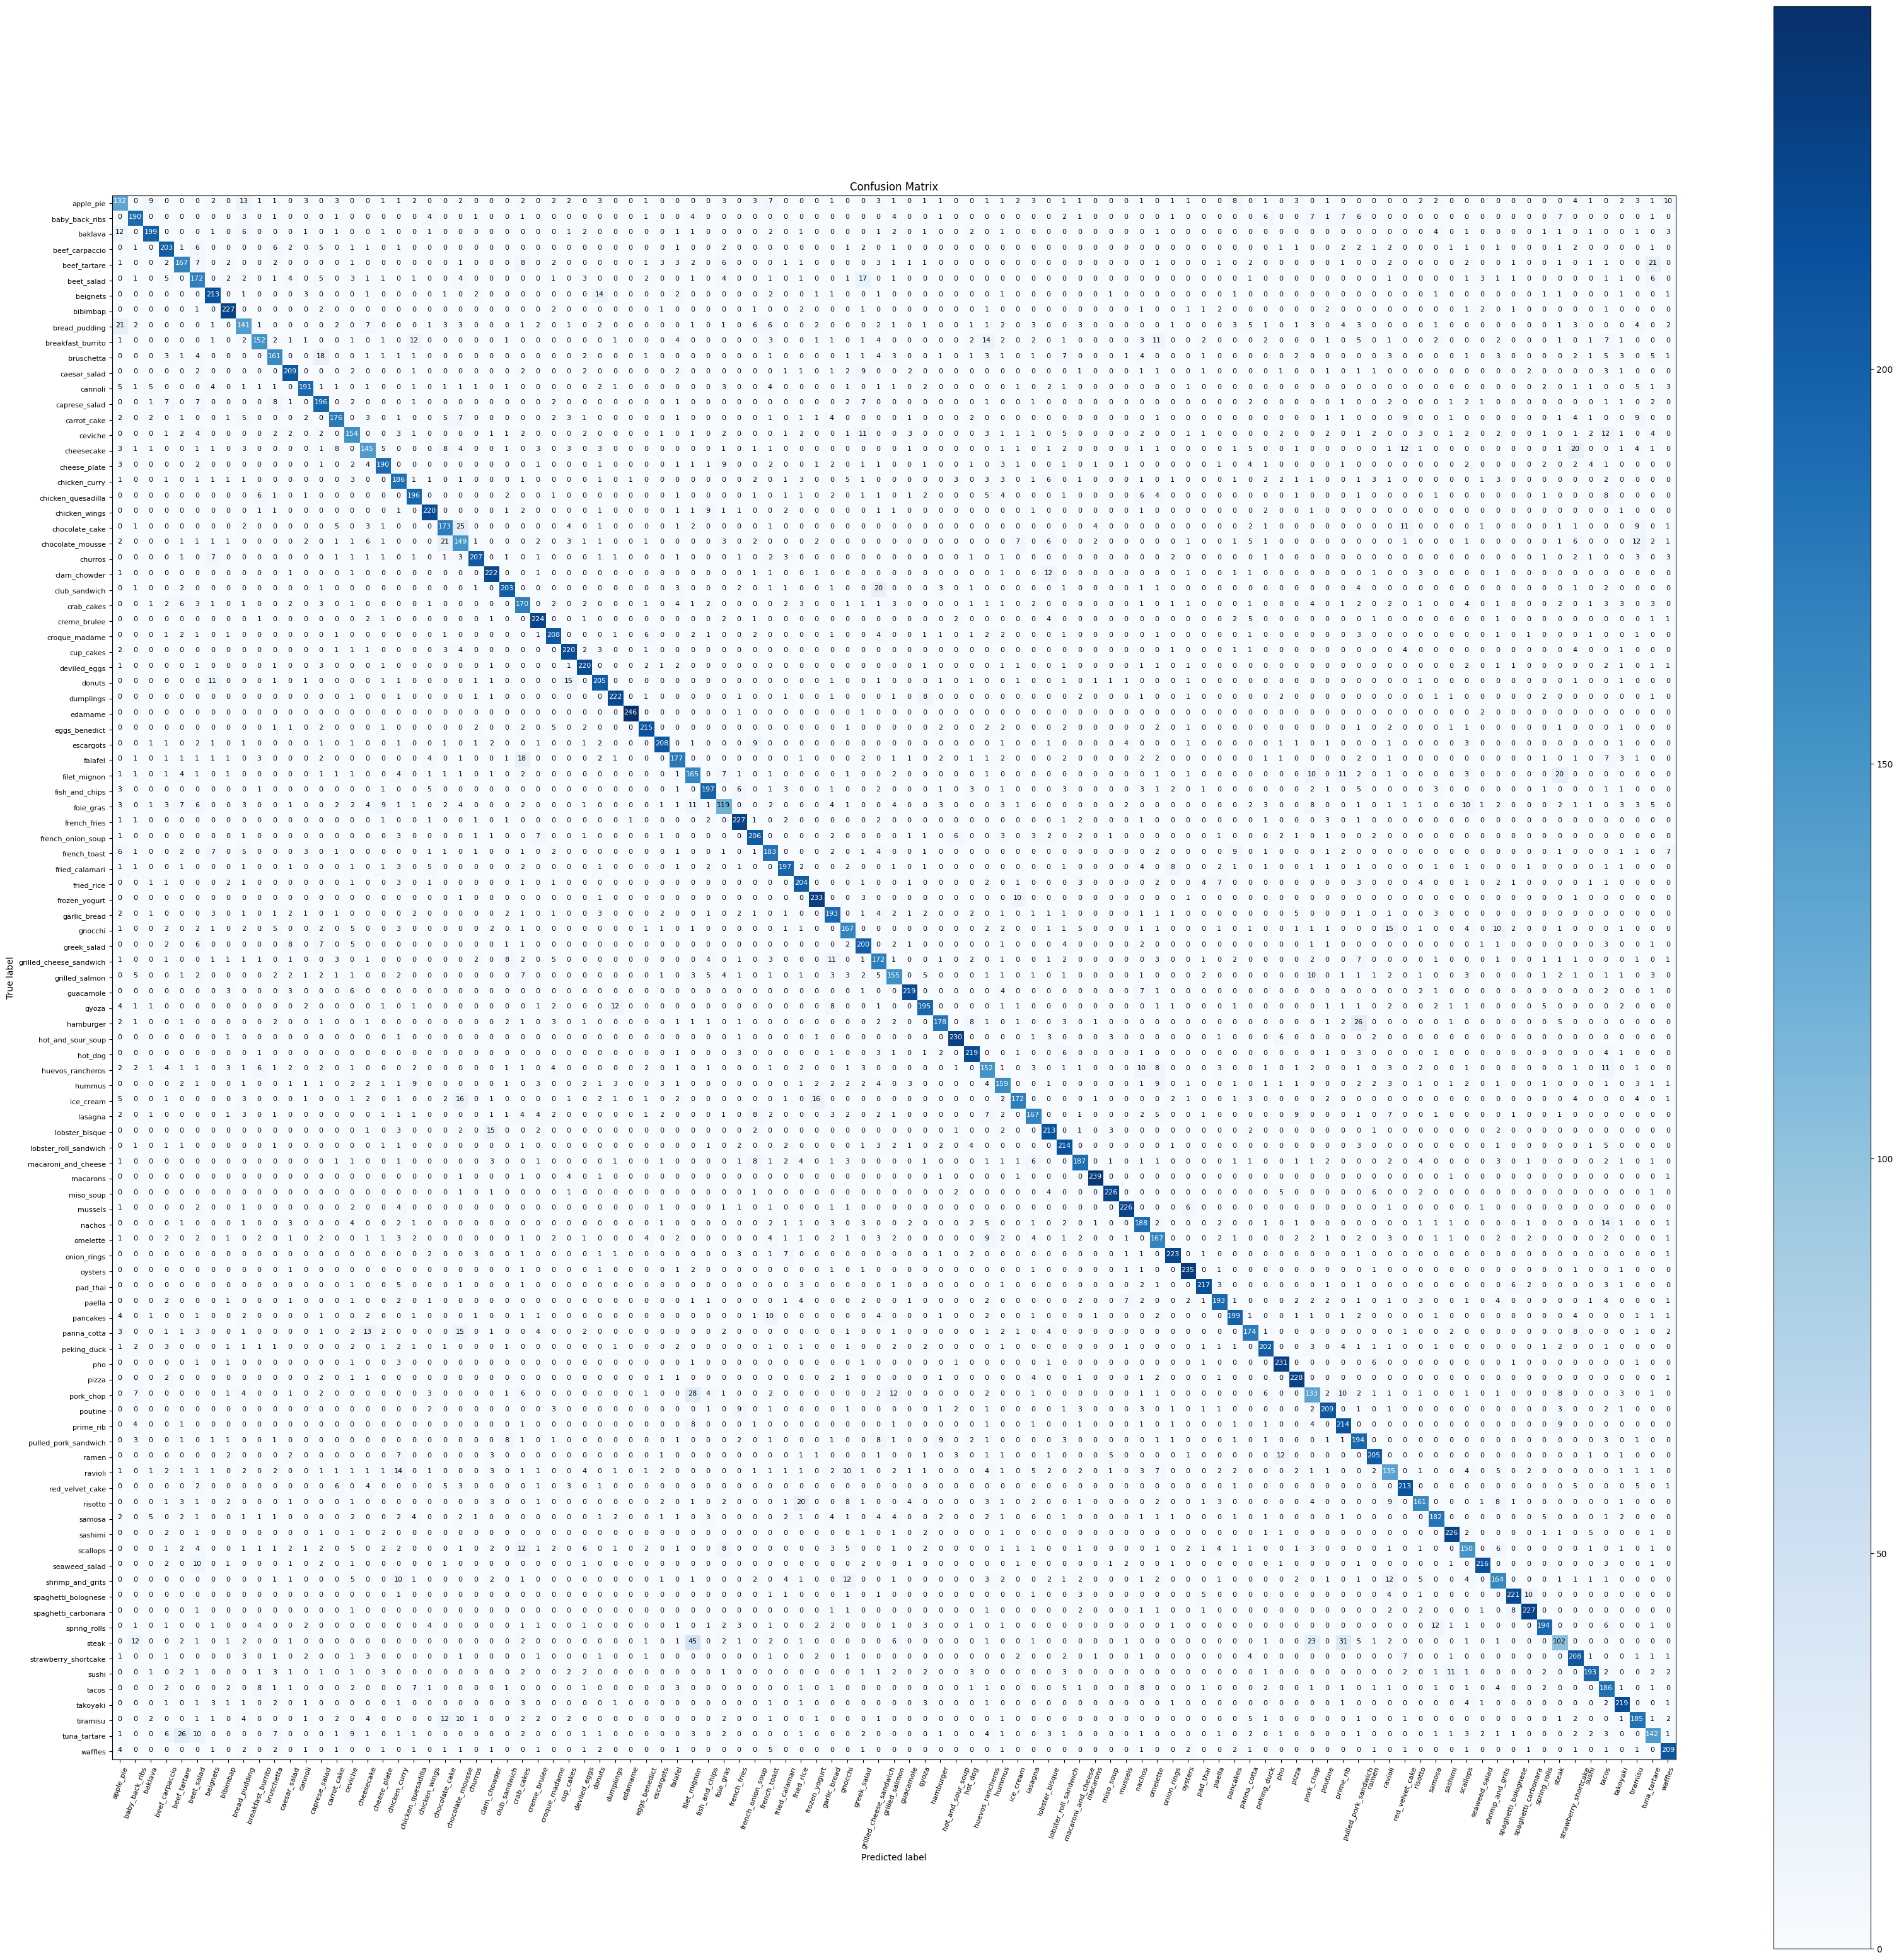

In [36]:
make_confusion_matrix(
    y_true=y_labels,
    y_pred=pred_classes,
    classes=class_names,
    figsize=(40, 40),
    text_size=8,
)

## Classification Report and Bar Plot


In [37]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true=y_labels,
        y_pred=pred_classes,
    )
)

# plotting class no. and f1 score

class_names = ds_info.features[
    "label"
].names

classification_report_dict = classification_report(
    y_labels, pred_classes, output_dict=True
)

class_f1_scores = {}

for class_name, metrics in classification_report_dict.items():
    if (
        class_name != "accuracy"
        and class_name != "macro avg"
        and class_name != "weighted avg"
    ):
        class_f1_scores[class_names[int(class_name)]] = metrics["f1-score"]

              precision    recall  f1-score   support

           0       0.55      0.53      0.54       250
           1       0.79      0.76      0.77       250
           2       0.85      0.80      0.82       250
           3       0.75      0.81      0.78       250
           4       0.68      0.67      0.67       250
           5       0.62      0.69      0.65       250
           6       0.80      0.85      0.83       250
           7       0.86      0.91      0.88       250
           8       0.61      0.56      0.59       250
           9       0.79      0.61      0.69       250
          10       0.71      0.64      0.68       250
          11       0.80      0.84      0.82       250
          12       0.86      0.76      0.81       250
          13       0.72      0.78      0.75       250
          14       0.79      0.70      0.75       250
          15       0.62      0.62      0.62       250
          16       0.67      0.58      0.62       250
          17       0.81    

In [38]:
import pandas as pd

f1_scores = pd.Series(class_f1_scores).sort_values(ascending=True)

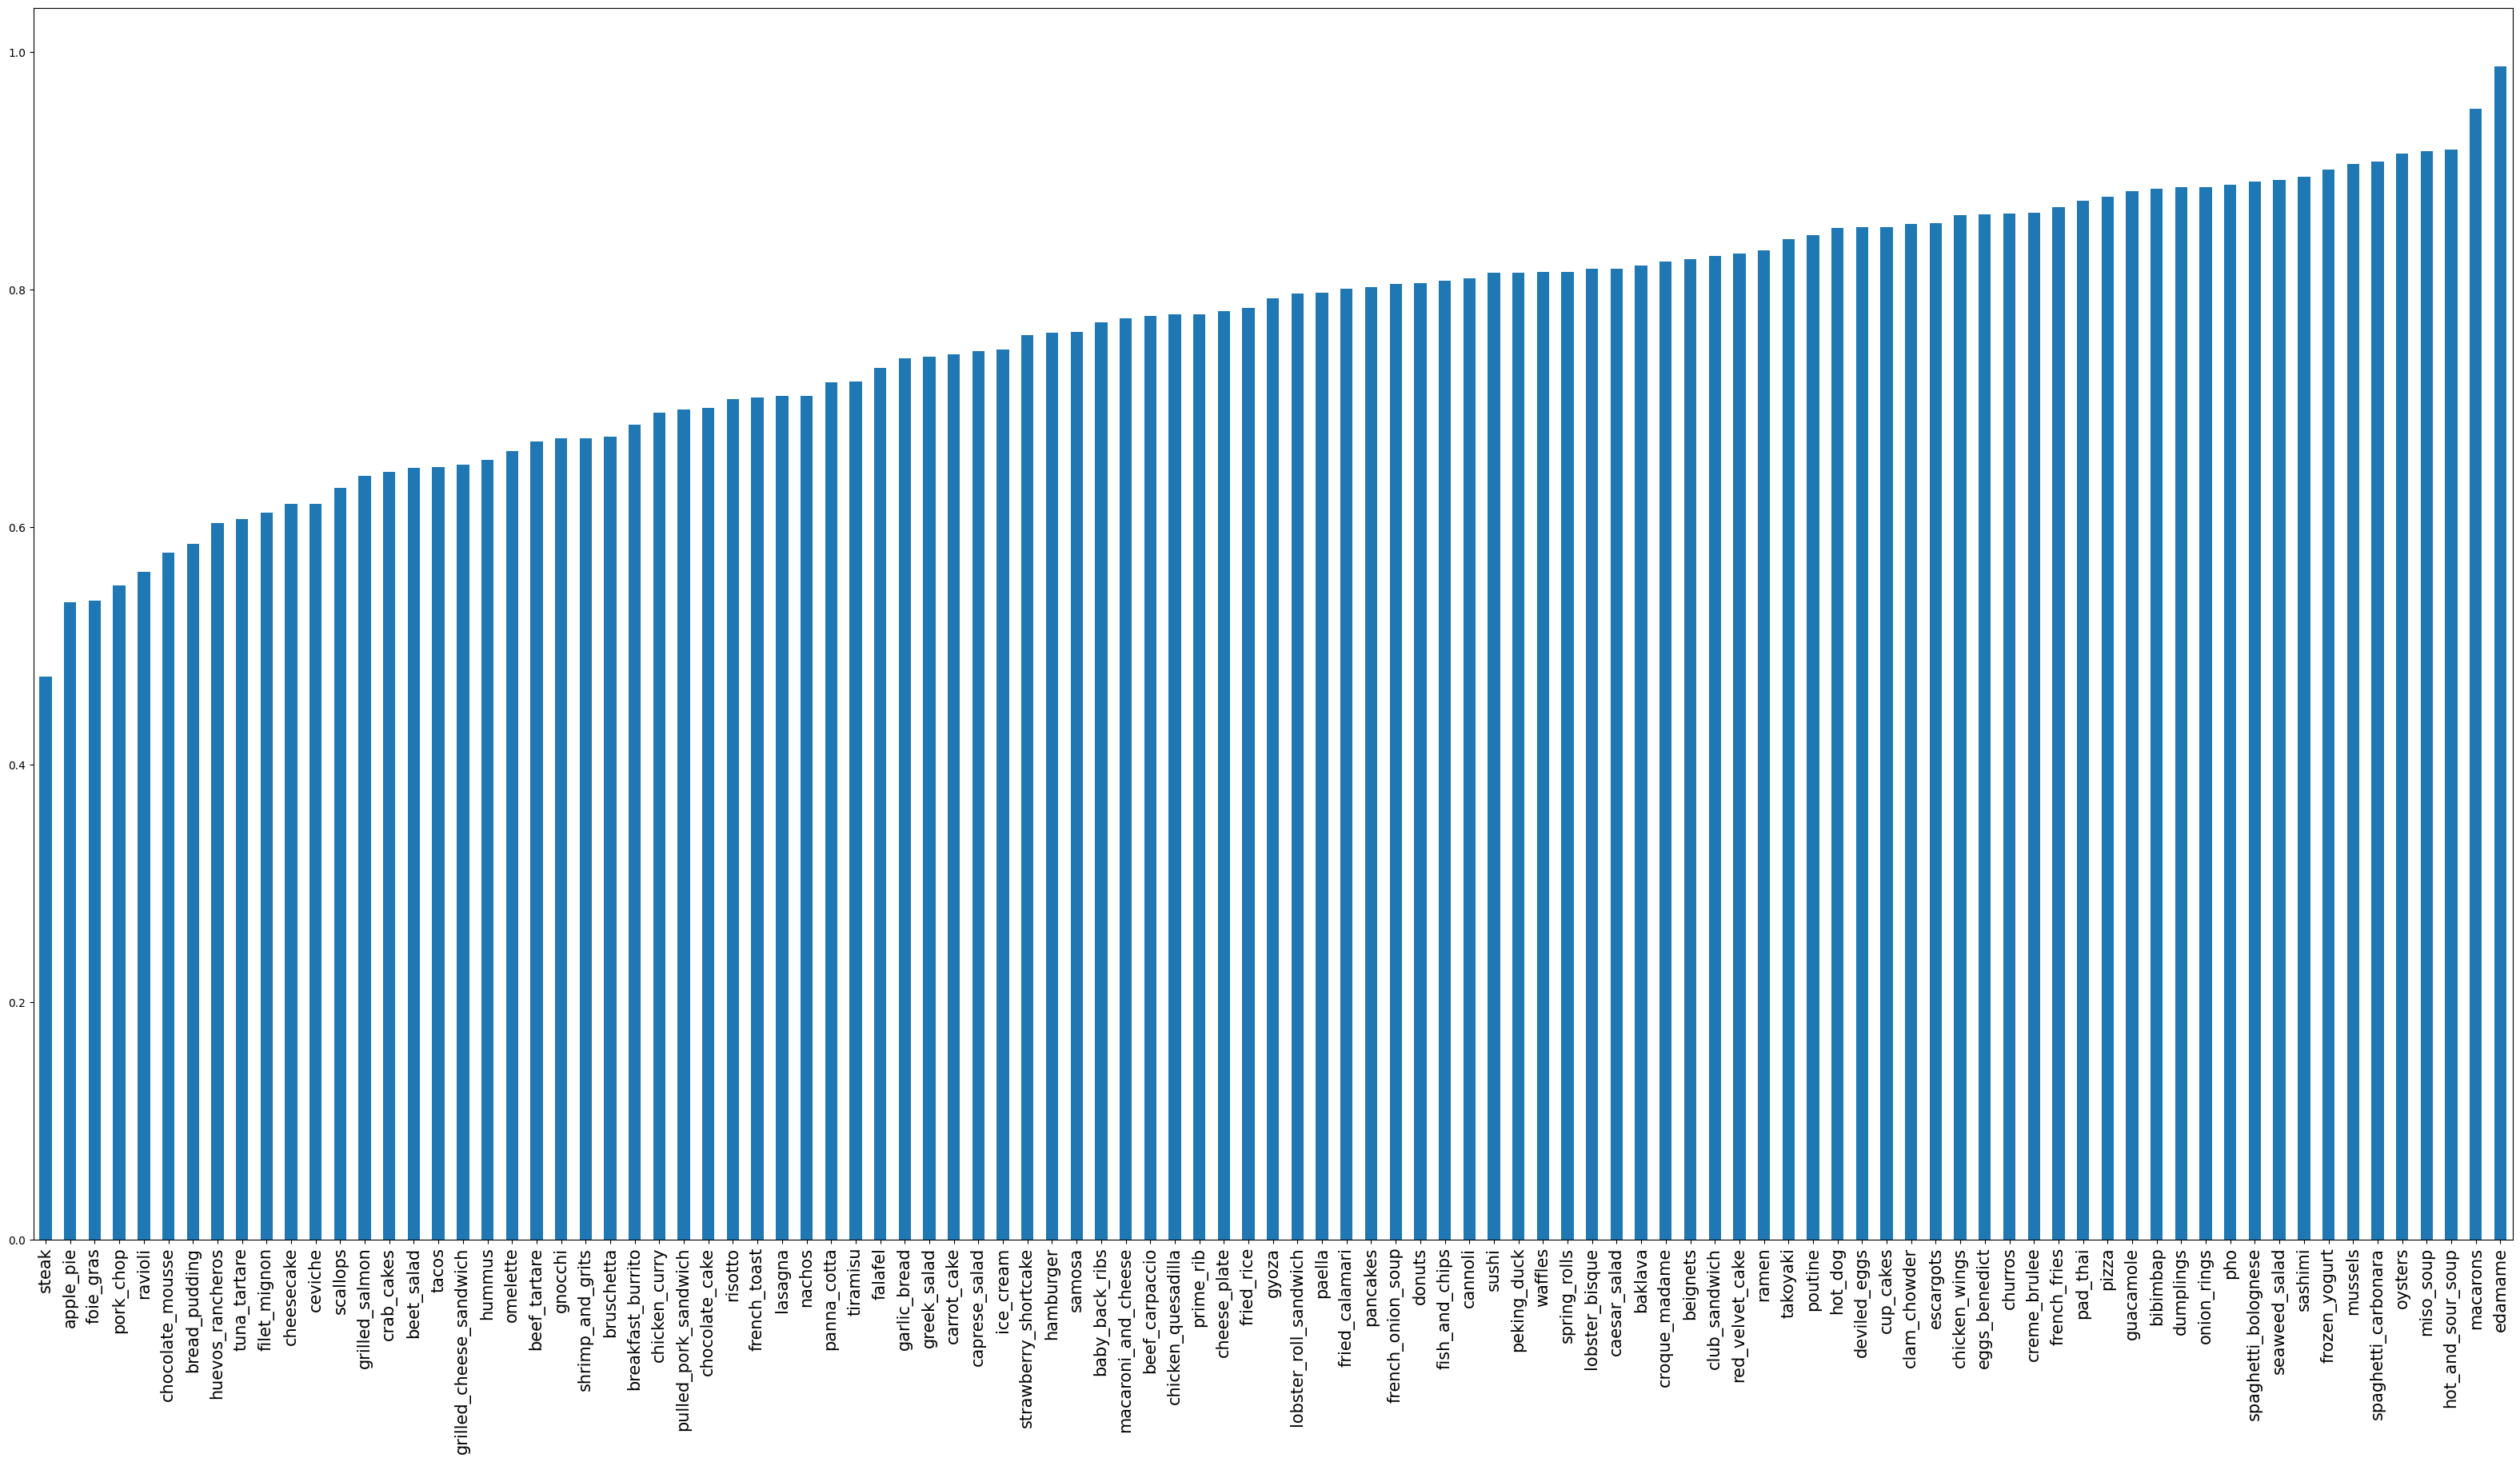

In [39]:
f1_scores.plot.bar(figsize=(40, 20))
plt.xticks(fontsize=15)
plt.show()